<a href="https://colab.research.google.com/github/Jorge-Ruiz-Troccoli/Data-Science-I/blob/main/Clase005/Visualizaciones_y_primeros_pasos_(parte_II).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Visualizaciones y primeros pasos (parte II)
### Coderhouse - Data Science
Profe Jorge Ruiz

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
penguins = sns.load_dataset("penguins")
penguins

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


In [ ]:
penguins.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


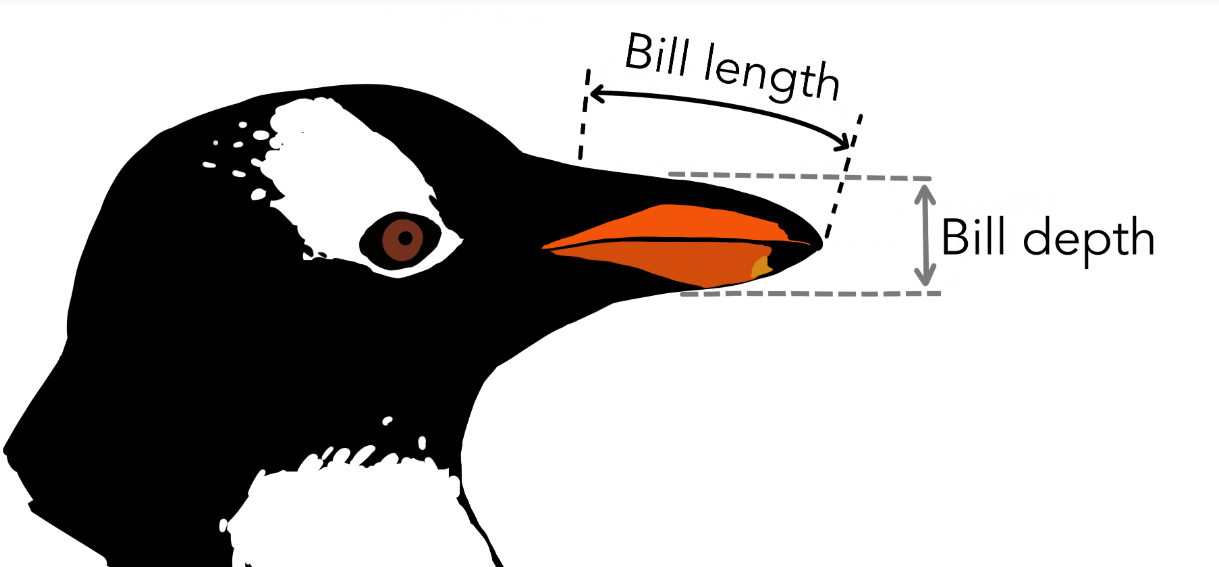

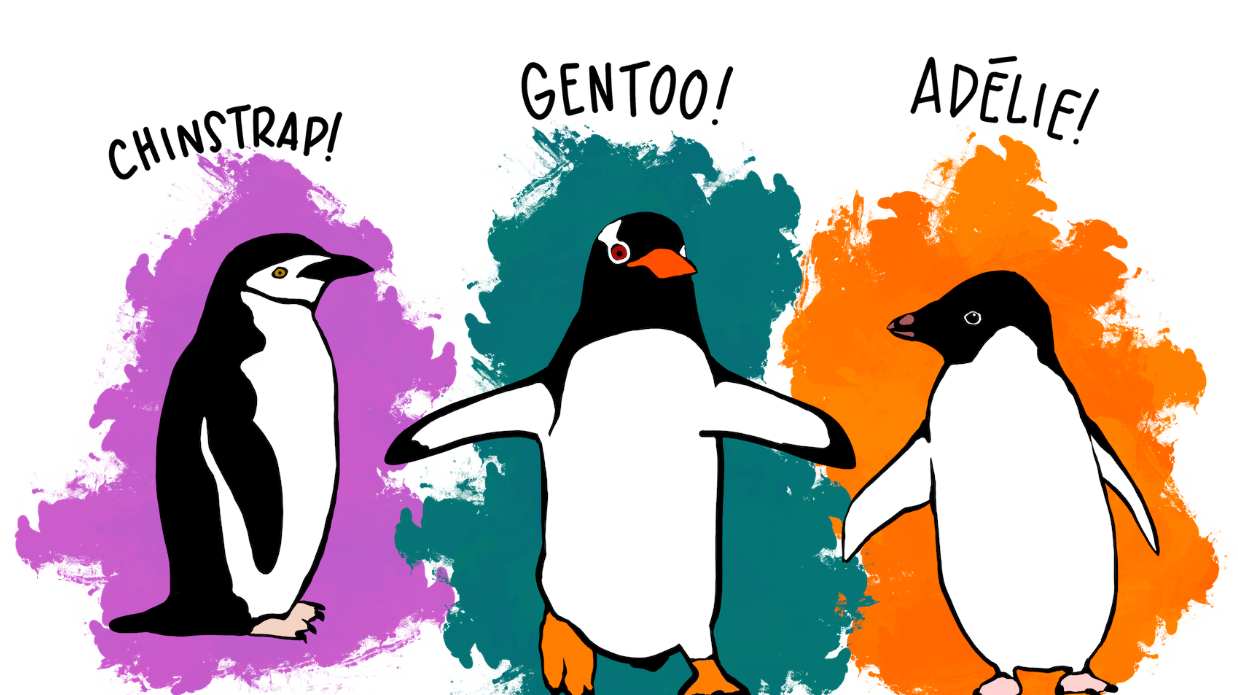

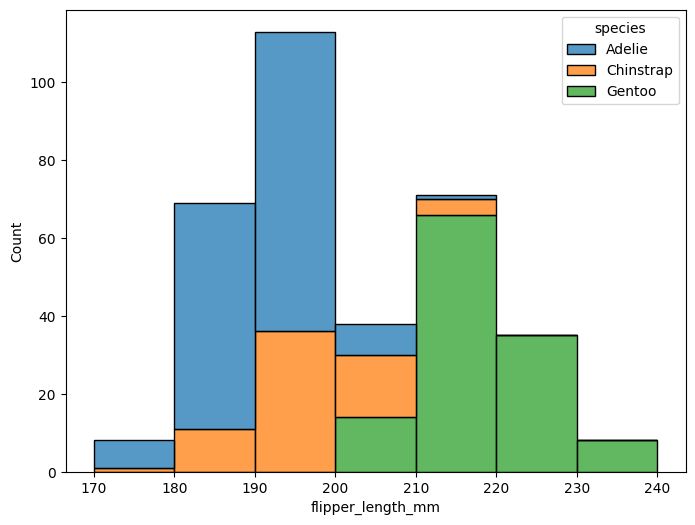

In [ ]:


"""
data=penguins especifica que los datos a utilizar se encuentran en el DataFrame penguins.
x="flipper_length_mm" establece que la variable a trazar en el eje X es la longitud de las aletas de los pingüinos, medida en milímetros.
hue="species" especifica que se quiere separar las barras del histograma por especies de pingüinos, utilizando diferentes colores para cada especie.
multiple="stack" indica que se quiere un histograma apilado (stacked), en el que las barras
correspondientes a cada especie se apilan unas sobre otras en lugar de superponerse.

revisar más información en https://seaborn.pydata.org/generated/seaborn.histplot.html
"""
# Crear la figura con el tamaño deseado
plt.figure(figsize=(8, 6))
bin_width = 10
bin_range = range(170, 250, bin_width)
# Axes-level
sns.histplot(data=penguins, x="flipper_length_mm", hue="species", multiple="stack", bins=bin_range)
stat="percent" #permite verlo en frecuencia relativa
plt.show()

'\nLa principal diferencia entre histplot y displot es que histplot traza histogramas, mientras que displot traza\ngráficos de distribución más generales, que pueden incluir histogramas, gráficos de densidad,\ngráficos de densidad de contorno, entre otros. Por lo tanto, displot es una función más versátil que histplot.\n\n '

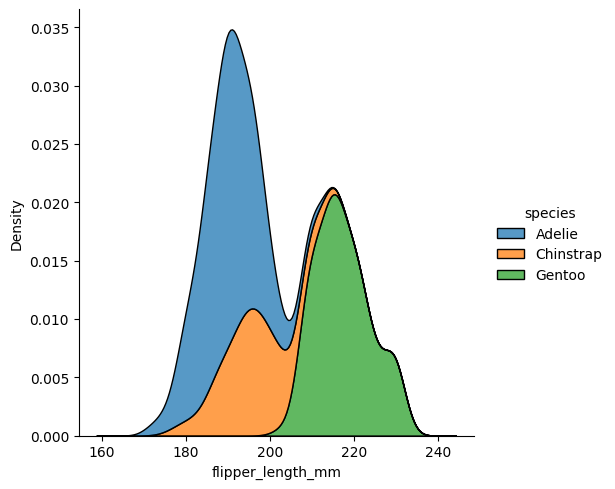

In [ ]:
# Figure-level
sns.displot(data=penguins, x="flipper_length_mm", hue="species", multiple="stack", kind="kde")

"""
La principal diferencia entre histplot y displot es que histplot traza histogramas, mientras que displot traza
gráficos de distribución más generales, que pueden incluir histogramas, gráficos de densidad,
gráficos de densidad de contorno, entre otros. Por lo tanto, displot es una función más versátil que histplot.

 """


<Axes: xlabel='flipper_length_mm', ylabel='Count'>

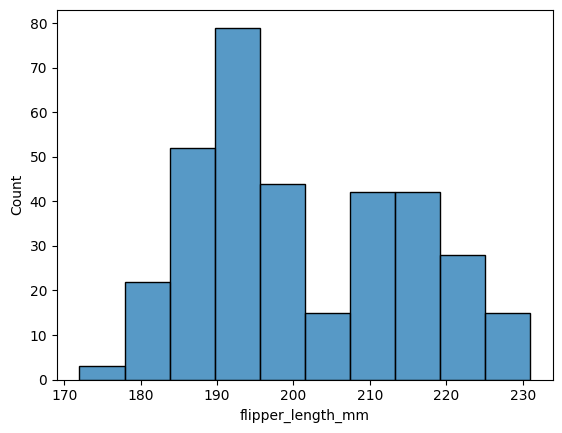

In [ ]:
# Histograma
penguins = sns.load_dataset("penguins")
# Axis-level
sns.histplot(data=penguins, x="flipper_length_mm")

<Axes: xlabel='flipper_length_mm', ylabel='Count'>

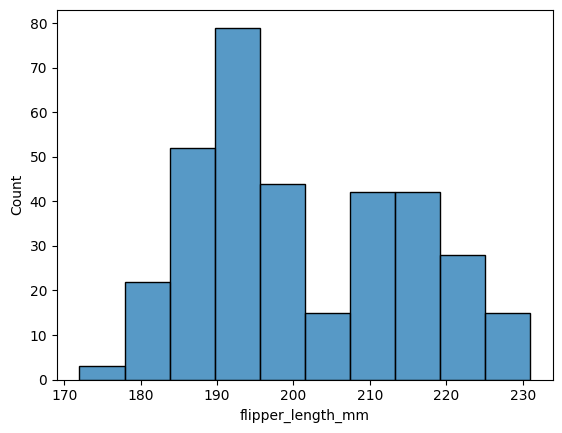

In [ ]:
sns.histplot(penguins["flipper_length_mm"])

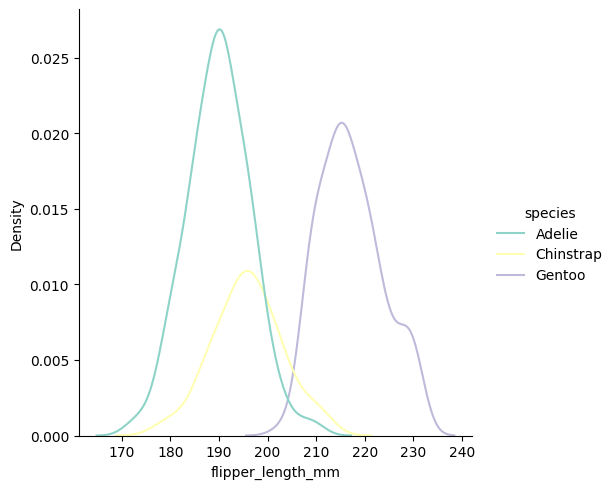

In [ ]:


sns.displot(data=penguins, x="flipper_length_mm", hue="species", kind="kde", multiple="layer", palette='Set3')
plt.show()

# https://seaborn.pydata.org/generated/seaborn.displot.html

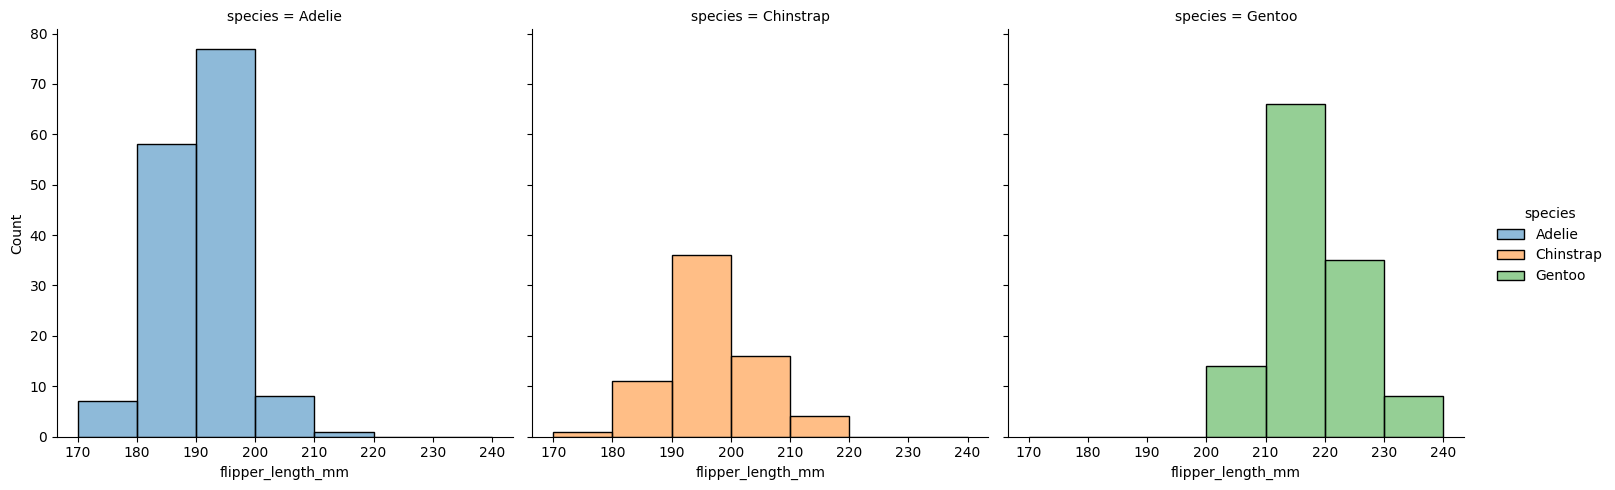

In [ ]:
# Multiples figuras (Figure-level)
"""
col="species": especifica que se desea crear un gráfico separado para cada especie de pingüino,
es decir, se creará una columna de gráficos para cada especie de pingüino en lugar de mostrar todos los datos en un solo gráfico.
"""
# establecer los límites y bines para el histograma
bin_width = 10
bin_range = range(170, 250, bin_width)

# crear un histograma de la longitud de la aleta de los pingüinos con seaborn
sns.displot(data=penguins, x="flipper_length_mm", hue="species", col="species", bins=bin_range)

#ahora se tiene gráficos de distribución separados

In [ ]:
 penguins["species"].unique()

array(['Adelie', 'Chinstrap', 'Gentoo'], dtype=object)

In [ ]:
penguins["species"].value_counts()

,count
species,
Adelie,152
Gentoo,124
Chinstrap,68


In [ ]:
penguins[penguins["species"]=="Adelie"][["flipper_length_mm"]]

,flipper_length_mm
0,181.0
1,186.0
2,195.0
3,NaN
4,193.0
...,...
147,184.0
148,195.0
149,193.0
150,187.0


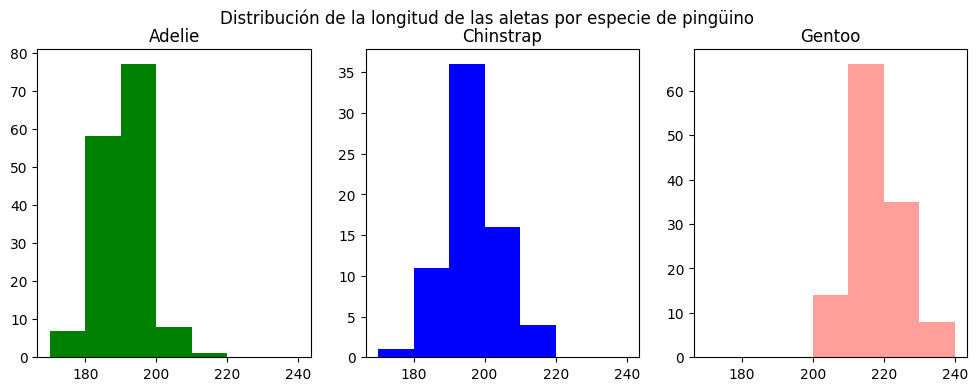

In [ ]:
# probemos hacer esto con matplotlib
# crear histogramas separados para cada especie de pingüino
fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(12, 4))


axs[0].hist(penguins[penguins["species"]=="Adelie"]["flipper_length_mm"], color="g", bins=bin_range)
axs[0].set_title("Adelie")


axs[1].hist(penguins[penguins["species"]=="Chinstrap"]["flipper_length_mm"], color="b", bins=bin_range)
axs[1].set_title("Chinstrap")

axs[2].hist(penguins[penguins["species"]=="Gentoo"]["flipper_length_mm"], color='#ff9f9b', bins=bin_range)
axs[2].set_title("Gentoo")


fig.suptitle("Distribución de la longitud de las aletas por especie de pingüino")
plt.show()

#claramente podemos observar como con sns es más sencillo

In [ ]:
penguins[penguins["species"]=="Adelie"]["flipper_length_mm"]

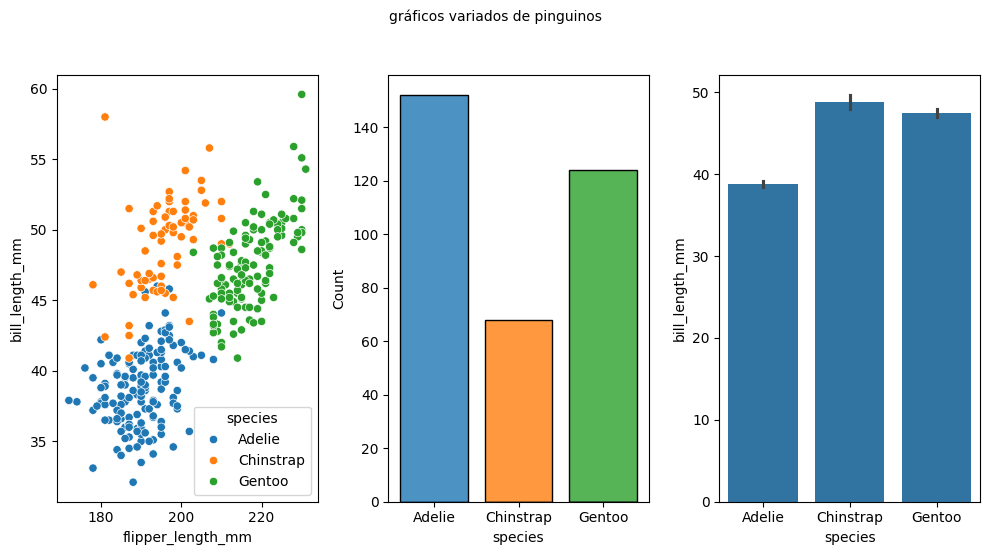

In [ ]:
# Axis level
"""
* f, axs = plt.subplots(1, 2, figsize=(10, 5), gridspec_kw=dict(width_ratios=[4, 3])) crea una figura (f) con dos subplots (axs[0] y axs[1])
utilizando la función subplots() de Matplotlib. El parámetro 1, 2 indica que se quiere una fila de dos subplots, mientras que figsize=(8, 4)
establece el tamaño de la figura.

* El parámetro gridspec_kw=dict(width_ratios=[5, 5]) establece la proporción de ancho entre los dos subplots

*sns.scatterplot(data=penguins, x="flipper_length_mm", y="bill_length_mm", hue="species", ax=axs[0]) traza una gráfica de dispersión utilizando la
función scatterplot() de Seaborn. La variable data especifica que los datos a utilizar se encuentran en el DataFrame penguins.
Los argumentos x e y especifican las variables a trazar en los ejes X e Y, respectivamente.
* El argumento hue especifica que se quiere separar los puntos por especies de pingüinos, utilizando diferentes colores para cada especie.

* El argumento ax=axs[0] indica que se quiere trazar la gráfica en el primer subplot (axs[0]).

* sns.histplot(data=penguins, x="species", hue="species", shrink=.8, alpha=.8, legend=False, ax=axs[1]) traza un histograma utilizando la función histplot()
de Seaborn. El argumento data especifica que los datos a utilizar se encuentran en el DataFrame penguins.

* El argumento x="species" especifica que se quiere trazar un histograma de la variable categórica "species".

* El argumento hue="species" especifica que se quiere separar las barras del histograma por especies de pingüinos, utilizando diferentes colores para cada especie.

* Los argumentos shrink=.8 y alpha=.8 ajustan el tamaño y la transparencia de las barras del histograma.

* El argumento legend=False desactiva la leyenda del histograma. El argumento ax=axs[1] indica que se quiere trazar el histograma en el segundo subplot (axs[1]).

* f.tight_layout() ajusta el espacio entre los subplots para que no se superpongan.
"""
f, axs = plt.subplots(1, 3, figsize=(10, 5), gridspec_kw=dict(width_ratios=[5, 5, 5]))

sns.scatterplot(data=penguins, x="flipper_length_mm", y="bill_length_mm", hue="species", ax=axs[0])
sns.histplot(data=penguins, x="species", hue="species", shrink=.8, alpha=.8, legend=False, ax=axs[1])
sns.barplot(data=penguins, x="species", y="bill_length_mm", ax=axs[2])

f.tight_layout()
f.suptitle("gráficos variados de pinguinos", fontsize=10, y=1.1)
plt.show()

In [ ]:
len(penguins)

In [ ]:

tips = sns.load_dataset("tips")
tips


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


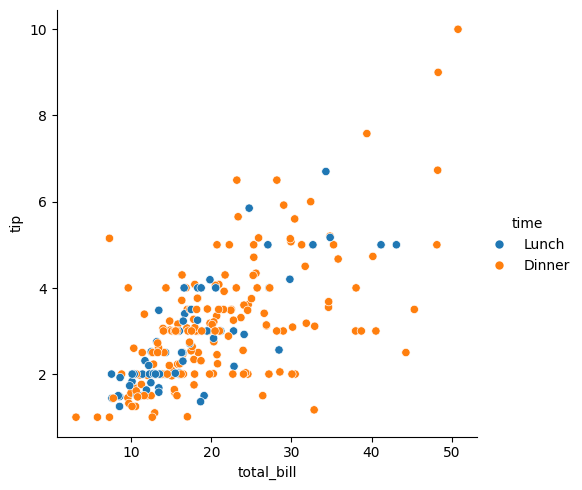

In [ ]:
"""
la función sns.relplot() es una función más general que se utiliza para crear una variedad de gráficos de relación
que pueden incluir gráficos de dispersión, como también líneas, barras, y otros tipos de gráficos.
sns.relplot() permite crear gráficos de dispersión con múltiples variables categóricas o numéricas, y permite
agregar subgráficos para mostrar diferentes aspectos de los datos.
"""


g = sns.relplot(data=tips, x="total_bill", y="tip", hue="time", kind="scatter")
# probar kind= "line"



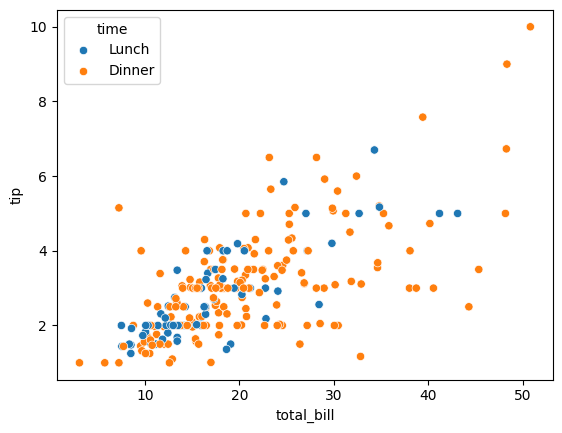

In [ ]:
sns.scatterplot(data=tips, x="total_bill", y="tip", hue="time")
plt.show()

# parece que hay propinas más elevadas en las cenas (cuidado con esa conclusión de manera firme)

In [ ]:
counts = tips["time"].value_counts()
counts

,count
time,
Dinner,176
Lunch,68


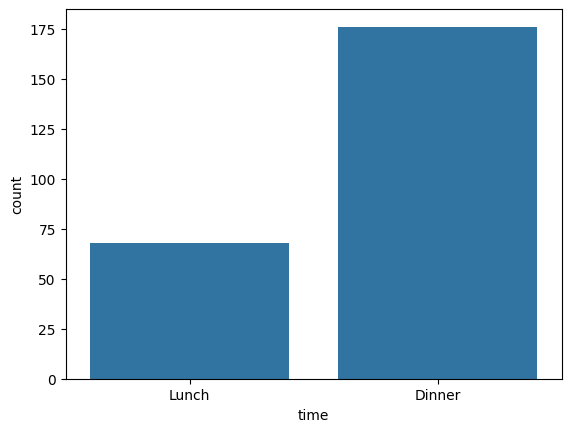

In [ ]:
sns.barplot(x=counts.index, y=counts)
plt.show()

# es un dataset desbalanceado, ya que hay más muestras de cenas que de almuerzos


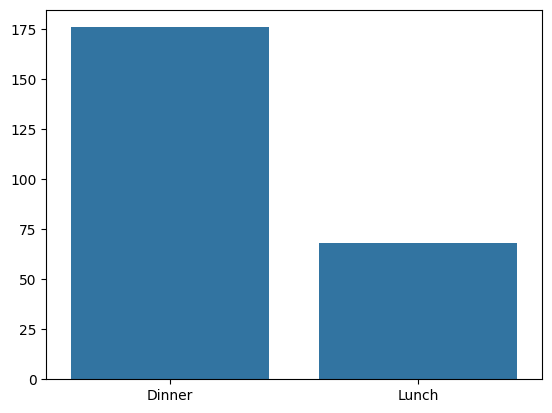

In [ ]:
data= np.unique(tips.time, return_counts=True)
sns.barplot(x=data[0], y=data[1])
plt.show()


In [ ]:
data

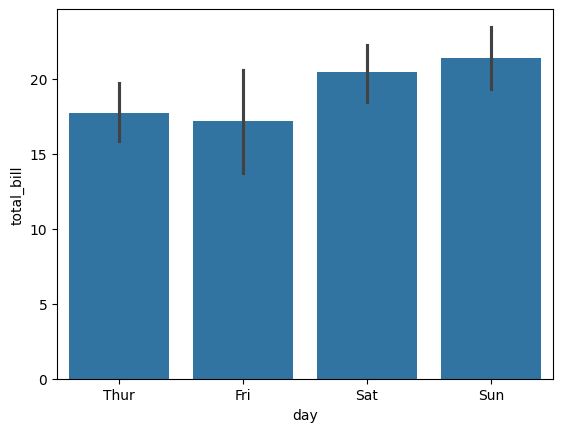

In [ ]:
#sns.barplot(x=tips["day"], y=tips["total_bill"], ci=None) # sin la barra de errror



# sns.barplot(x="day", y="total_bill", data=tips) versión alternativa

"""
El límite inferior del error bar representa el valor más bajo que se espera que tenga la media de la población con una probabilidad del 90%
(o cualquier otro nivel de confianza especificado). De manera similar, el límite superior del error bar representa el valor más alto que se espera
 que tenga la media de la población con una probabilidad del 90% (o cualquier otro nivel de confianza especificado).

En general, cuanto más larga sea la línea del error bar, mayor será la incertidumbre en la estimación de la media de cada categoría y,
 por lo tanto, menos precisa será la medida. Por otro lado, cuanto más corta sea la línea del error bar, menor será la incertidumbre en la
 estimación de la media de cada categoría y, por lo tanto, más precisa será la medida.
"""

sns.barplot(x=tips["day"], y=tips["total_bill"])
plt.show()

In [ ]:
tips["day"].value_counts(normalize=True)*100

,proportion
day,
Sat,35.655738
Sun,31.147541
Thur,25.409836
Fri,7.786885


In [ ]:
#calcular la media
tips[tips["day"]=="Thur"]["total_bill"].mean().round(1)

np.float64(17.7)

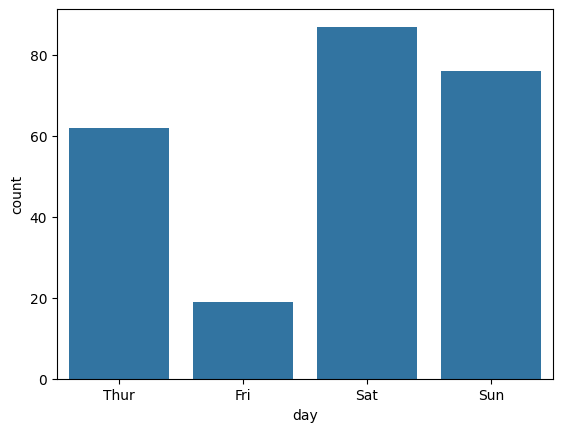

In [ ]:
counts = tips["day"].value_counts()
sns.barplot(x=counts.index, y=counts)
plt.show()



In [ ]:
counts

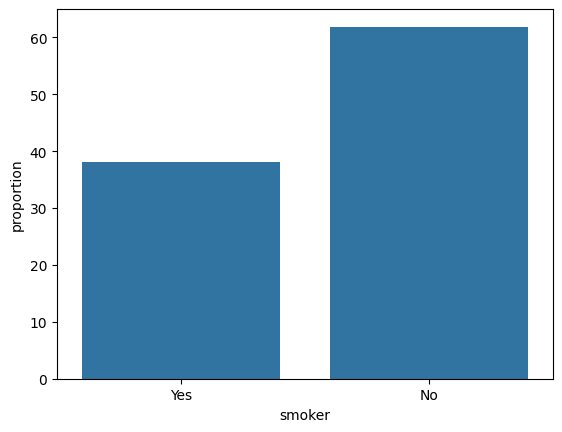

In [ ]:
counts = tips["smoker"].value_counts(normalize=True)*100
sns.barplot(x=counts.index, y=counts)
plt.show()

#hay muchos más clientes no fumadores

In [ ]:
#calcular la media de total_bill de los fumadores los días jueves


tips[(tips["day"] == "Thur") & (tips["smoker"] == "Yes") ]["total_bill"].mean().round(1)

# para "o" se usa el operador "|" pipe
# para el "y" se usa el operador "&"

np.float64(19.2)

<Axes: xlabel='day', ylabel='total_bill'>

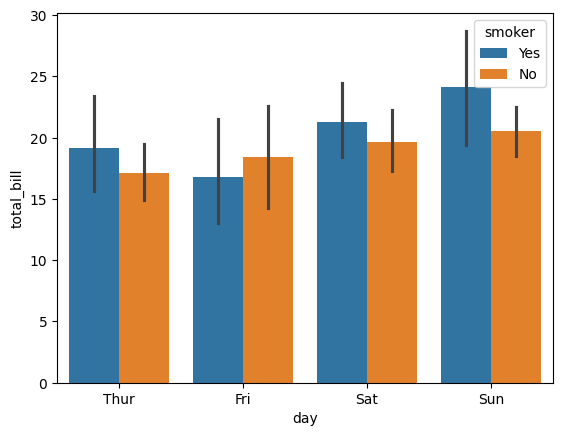

In [ ]:
sns.barplot(x="day", y="total_bill", data=tips, hue='smoker')

#parece que los fumadores aunque son menos consumen muy similar a los no fumadores, algunas veces un poco más (esto en promedio)

<Axes: xlabel='day', ylabel='total_bill'>

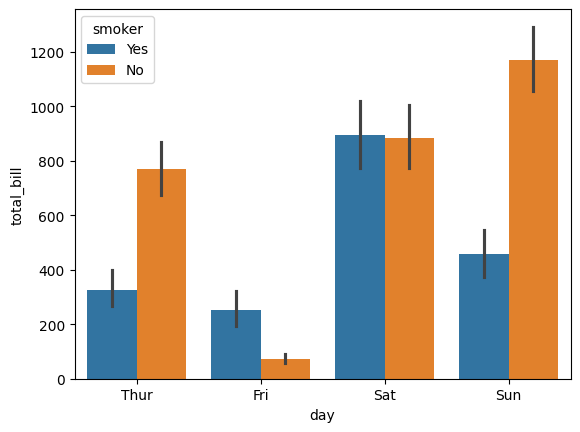

In [ ]:
import numpy as np


sns.barplot(x="day", y="total_bill", data=tips, hue='smoker', estimator="sum")
#sns.barplot(x="day", y="total_bill", data=tips, hue='smoker', estimator=np.sum)

<Axes: xlabel='day', ylabel='total_bill'>

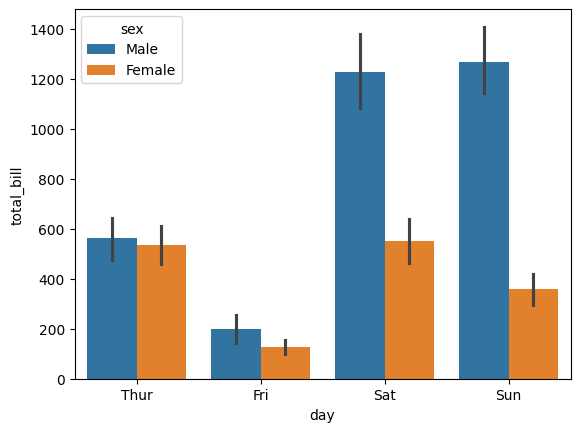

In [ ]:
#sns.barplot(x="day", y="total_bill", hue="sex", data=tips, estimator=np.sum)
sns.barplot(x="day", y="total_bill", hue="sex", data=tips, estimator="sum")

In [ ]:
tips.sex.value_counts(normalize=True)*100

,proportion
sex,
Male,64.344262
Female,35.655738


In [ ]:

flights = sns.load_dataset("flights")
flights.head()

,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121


<Axes: xlabel='year', ylabel='passengers'>

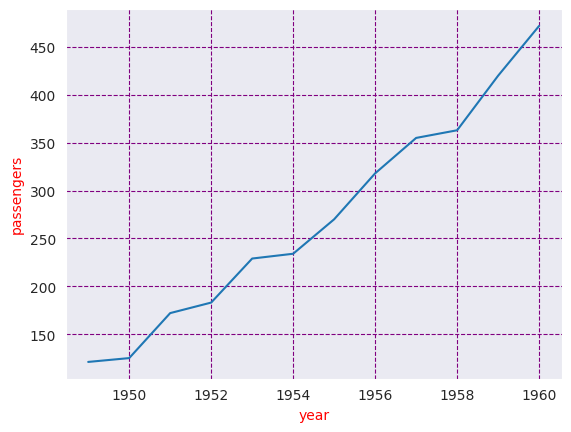

In [ ]:
# Axis-level
may_flights = flights[flights["month"]=="May"]
sns.lineplot(data=may_flights, x="year", y="passengers")

In [ ]:
# Axis-level
#flights_wide = flights.pivot("year", "month", "passengers")
flights_wide = flights.pivot(index="year", columns="month", values="passengers")
flights_wide.head()


month,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
year,,,,,,,,,,,,
1949,112,118,132,129,121,135,148,148,136,119,104,118
1950,115,126,141,135,125,149,170,170,158,133,114,140
1951,145,150,178,163,172,178,199,199,184,162,146,166
1952,171,180,193,181,183,218,230,242,209,191,172,194
1953,196,196,236,235,229,243,264,272,237,211,180,201


<Axes: xlabel='year'>

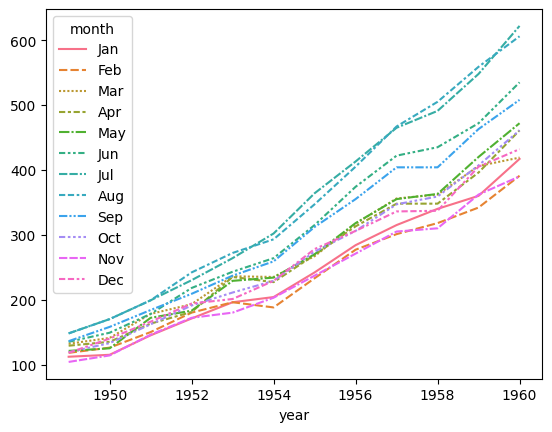

In [ ]:
sns.lineplot(data=flights_wide)

In [ ]:
sns.set_style(style="darkgrid", rc={"grid.color": ".6"})
sns.set_style(rc={"grid.linestyle": ":"})
sns.set_style(rc={"axes.titleweight": "normal"})
sns.set_style(rc={"axes.titlelocation": "left"})
sns.set_style(rc={"axes.titlecolor": "blue"})
sns.set_style(rc={"axes.labelcolor": "red"})
sns.set_style(rc={"axes.labelsize": "12"})
sns.set_style(rc={"axes.labelweight": "normal"})
sns.set_style(rc={"axes.linewidth": "0.5"})
sns.set_style(rc={"grid.color": "purple"})
sns.set_style(rc={"grid.linestyle": "--"})
sns.set_style(rc={"grid.linewidth": "0.5"})
sns.set_style(rc={"font.fantasy": "Comic Sans MS"})
sns.set_style(rc={"font.serif": "Utopia"})

#revisar https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.set_title.html

<Axes: xlabel='flipper_length_mm', ylabel='Count'>

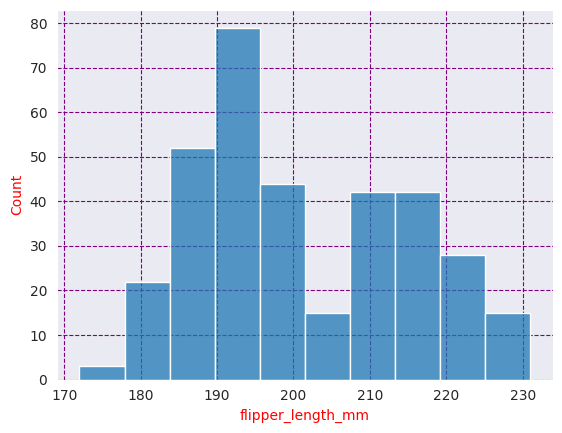

In [ ]:
penguins = sns.load_dataset("penguins")
# Axis-level
sns.histplot(data=penguins, x="flipper_length_mm")

In [ ]:
sns.reset_orig()
#valores por defecto nuevamente

BoxPlot

In [ ]:
#se recomienda leer https://www.kdnuggets.com/2019/11/understanding-boxplots.html

#Q1= p25
#Q2= p50= mediana
#Q3= p75

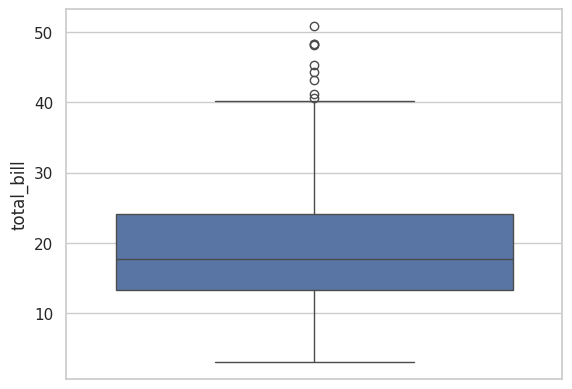

In [ ]:
import seaborn as sns
sns.set_theme(style="whitegrid")
tips = sns.load_dataset("tips")
# Axis-level
ax = sns.boxplot(y=tips["total_bill"])

# probar con ax = sns.boxplot(x=tips["total_bill"])


In [ ]:
# Axis-level
ax = sns.boxplot(x="day", y="total_bill", data=tips)